In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO


pep_hits_long = pd.read_csv('long_weak_neut_samples_092426.csv')

In [33]:
pep_hits_long.shape

(242200, 18)

In [34]:
lassa = pep_hits_long[pep_hits_long['species'] == 'Mammarenavirus lassaense'].copy()

## importing the reference sequences fetched from UniProt (UP000002473_11622.fasta)

In [35]:
records = list(SeqIO.parse('UP000002473_11622_LASV_Josiah_reference.fasta', 'fasta'))

for r in records:
    print(r.id, len(r.seq))

sp|O09705|L_LASSJ 2218
sp|O73557|Z_LASSJ 99
sp|P08669|GLYC_LASSJ 491
sp|P13699|NCAP_LASSJ 569


In [36]:
reference_by_protein = {
    "polymerase": str(next(r.seq for r in records if "O09705" in r.id)),
    "glycoprotein": str(next(r.seq for r in records if "P08669" in r.id)),
    "nucleoprotein": str(next(r.seq for r in records if "P13699" in r.id)),
    "z protein": str(next(r.seq for r in records if "O73557" in r.id)),
}

In [37]:
print(lassa['category'].value_counts())
print(lassa['sequence'].nunique())
print(lassa['protein_std'].unique())

category
Household contact    8772
Lassa survivor       4128
Name: count, dtype: int64
258
['nucleoprotein' 'polymerase' 'glycoprotein' 'z protein']


## import PairwiseAligner and use BLOSUM62 matrix for local protein alignment

In [38]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

aligner = PairwiseAligner()
aligner.mode = 'local' #want the peptide to find its best location within the reference

aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

## choose glycoprotein

In [39]:
ref = reference_by_protein['glycoprotein']

np = lassa[lassa['protein_std'].eq("glycoprotein")].copy()

unique_np_peptides = np['sequence'].drop_duplicates()

In [40]:
ref

'MGQIVTFFQEVPHVIEEVMNIVLIALSVLAVLKGLYNFATCGLVGLVTFLLLCGRSCTTSLYKGVYELQTLELNMETLNMTMPLSCTKNNSHHYIMVGNETGLELTLTNTSIINHKFCNLSDAHKKNLYDHALMSIISTFHLSIPNFNQYEAMSCDFNGGKISVQYNLSHSYAGDAANHCGTVANGVLQTFMRMAWGGSYIALDSGRGNWDCIMTSYQYLIIQNTTWEDHCQFSRPSPIGYLGLLSQRTRDIYISRRLLGTFTWTLSDSEGKDTPGGYCLTRWMLIEAELKCFGNTAVAKCNEKHDEEFCDMLRLFDFNKQAIQRLKAEAQMSIQLINKAVNALINDQLIMKNHLRDIMGIPYCNYSKYWYLNHTTTGRTSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMERQGKTPLGLVDLFVFSTSFYLISIFLHLVKIPTHRHIVGKSCPKPHRLNHMGICSCGLYKQPGVPVKWKR'

## define mapping function

In [41]:
def map_peptide_to_reference(peptide, reference, aligner):
    """
    goal: map a peptide onto a reference protein. 

    output: returns a dictionary containing
    - alignment score
    - reference start/end (1-based)
    - reference positions covered by aligned peptide residues
    """

    #if no exact substring match, use local alignment
    alignment = aligner.align(reference, peptide)[0] #[0] to extract the first and best-scoring Alignment object from the results

    #aligner.align[0].aligned returns the start and end coordinates of the aligned segments for the target and query sequences
    ref_blocks, peptide_blocks = alignment.aligned

    ref_positions = []

    for (ref_start, ref_end), (pep_start, pep_end) in zip(ref_blocks, peptide_blocks):
        
        for i in range(ref_end - ref_start):
            ref_positions.append(ref_start + i + 1) #1-based

    #overall peptide coordinates
    pep_start = peptide_blocks[0][0] + 1
    pep_end = peptide_blocks[-1][1] #take the last block,so -1, in case there are more than one aligned blocks. and [1] for the end

    #total number of peptide residues included in the aligned blocks
    aligned_length = sum(end - start for start, end in peptide_blocks)

    #total number 

    return{
        'score': alignment.score, 
        'ref_start': ref_positions[0],
        'ref_end': ref_positions[-1],
        'ref_positions': ref_positions, 
        'pep_start' : pep_start, 
        'pep_end': pep_end,
        'aligned_length': aligned_length
    }


In [42]:
mapping = []

for peptide in unique_np_peptides:
    result = map_peptide_to_reference(peptide, ref, aligner)

    mapping.append({
        'sequence': peptide, 
        'score': result['score'], 
        'ref_start': result['ref_start'], 
        'ref_end': result['ref_end'], 
        'ref_positions': result['ref_positions'], 
        'pep_start': result['pep_start'], 
        'pep_end': result['pep_end'], 
        'aligned_pep_length': result['aligned_length']

    })

np_mapping = pd.DataFrame(mapping)

In [43]:
#check the length of peptide alignment, should be ~46

np_mapping['alignment_length'] = np_mapping['ref_positions'].str.len()

np_mapping['alignment_length'].describe()

count    17.0
mean     46.0
std       0.0
min      46.0
25%      46.0
50%      46.0
75%      46.0
max      46.0
Name: alignment_length, dtype: float64

In [44]:
np_mapping.sort_values('aligned_pep_length').head(2)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
0,TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK,243.0,380,425,"[380, 381, 382, 383, 384, 385, 386, 387, 388, ...",1,46,46,46
1,SSNLYKGVYELQSLDLNMETLNMTMPLSCTKNNSHHYIRVGNETGL,219.0,58,103,"[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",1,46,46,46


In [45]:
#inspect the shortest mappings: 
np_mapping.sort_values("alignment_length").head(10)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
0,TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK,243.0,380,425,"[380, 381, 382, 383, 384, 385, 386, 387, 388, ...",1,46,46,46
1,SSNLYKGVYELQSLDLNMETLNMTMPLSCTKNNSHHYIRVGNETGL,219.0,58,103,"[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",1,46,46,46
2,CNEKHDEEFCDMWRLFDFNKQAIQRLKAEAQMNIQLINKAVNALIN,227.0,301,346,"[301, 302, 303, 304, 305, 306, 307, 308, 309, ...",1,46,46,46
3,FHLSIPNFNQYEAMSCDFNGGKISIQYNLSHSYAGDAAQHCGTVAN,247.0,140,185,"[140, 141, 142, 143, 144, 145, 146, 147, 148, ...",1,46,46,46
4,NDQLIMKNHLRDIMGIPYCNYSKYWYLNNTVTGKSSLPKCWLVSNG,247.0,346,391,"[346, 347, 348, 349, 350, 351, 352, 353, 354, ...",1,46,46,46
5,YWYLNNTVTGKSSLPKCWLVSNGSYLNETHFSEDIEQQADNMITEM,235.0,369,414,"[369, 370, 371, 372, 373, 374, 375, 376, 377, ...",1,46,46,46
6,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTVTGKTSLPKCWLVSNGS,256.0,347,392,"[347, 348, 349, 350, 351, 352, 353, 354, 355, ...",1,46,46,46
7,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTITGKTSLPRCWLVSNGS,252.0,347,392,"[347, 348, 349, 350, 351, 352, 353, 354, 355, ...",1,46,46,46
8,WYLNHTITGKTSLPRCWLVSNGSYLNETQFSDDIEQQADNMITELL,232.0,370,415,"[370, 371, 372, 373, 374, 375, 376, 377, 378, ...",1,46,46,46
9,LELDMANLNMTMPLSCTKNNSHHYIMVGNETGLELTLTNTSIINHK,226.0,71,116,"[71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 8...",1,46,46,46


## merging the mapping back to the individual-level dataframe


In [46]:
np = np.merge(np_mapping, on='sequence', how='left')

In [47]:
np.shape

(850, 26)

## .explode() turns one peptide/individual row to one row per amino-acid position covered by that peptide

In [48]:
np_residues = np.explode('ref_positions').rename(columns={'ref_positions': 'position'})

## keep only reactive peptides

In [49]:
reactive_residues = np_residues[np_residues['reactive']].copy()

## now we have the people and amino acid positions at which they have nucleoprotein antibody reactivity. But we need to remove contributions to the same amino-acid position. each individual can contribute at most one to a given amino acid position. 

In [50]:
reactive_residues = reactive_residues[['individual', 'cohort', 'category', 'position']].drop_duplicates()

In [51]:
reactive_residues['individual'].unique() #no US healthies, as expected

array(['C-464-3_3_F9', 'C-470-3_2_F8', 'C-489-2_3_D5', 'C-508-2_4_A8',
       'S-488_SA1_H2', 'C-191-3_1_A3', 'C-462-3_2_I6', 'C-507-3_4_B8',
       'S-486_SA1_H1', 'C-113-3_1_G6', 'C-469-3_7_H6', 'C-441-2_3_E6',
       'C-485-2_2_H6', 'S-183_SA1_G2', 'S-508_SA3_H8', 'C-134-1_2_D7',
       'C-145-1_2_I4', 'C-181-3_2_I9', 'C-190-2_2_I5', 'C-434-2_2_B7',
       'C-461-1_3_F1', 'C-483-2_3_D6', 'C-488-3_1_I3', 'C-489-3_1_I7',
       'C-511-2_4_A2', 'C-513-2_3_I2', 'S-182_SA4_D9', 'S-504_SA3_D8'],
      dtype=object)

## calculate number of individuals in each category

In [52]:
group_sizes = (
    np[['individual', 'cohort', 'category']].drop_duplicates().groupby(['cohort', 'category']).size().rename('n_individuals').reset_index()
)

group_sizes

,cohort,category,n_individuals
0,SL,Household contact,34
1,SL,Lassa survivor,16


## now count reactive individuals at each position

In [53]:
position_counts = (
    reactive_residues.groupby(['cohort', 'category', 'position'])['individual'] #reactive residues only include SL individuals
    .nunique()
    .rename('n_seroreactive')
    .reset_index()
)

position_counts.head(2)

,cohort,category,position,n_seroreactive
0,SL,Household contact,58,1
1,SL,Household contact,59,1


In [54]:
position_summary = position_counts.merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary.head(2)

,cohort,category,position,n_seroreactive,n_individuals
0,SL,Household contact,58,1,34
1,SL,Household contact,59,1,34


In [55]:
position_summary['pct_seroreactive'] = (
    position_summary['n_seroreactive'] / position_summary['n_individuals'] * 100
)

In [56]:
position_summary.head(3)

,cohort,category,position,n_seroreactive,n_individuals,pct_seroreactive
0,SL,Household contact,58,1,34,2.941176
1,SL,Household contact,59,1,34,2.941176
2,SL,Household contact,60,1,34,2.941176


## add positions with zero seroreactivity 

In [57]:
all_positions = pd.DataFrame({'position': range(1, len(ref) + 1)}) #initiate a dataframe with one column

groups = np[['cohort', 'category']].drop_duplicates()

complete_grid = groups.merge(all_positions, how='cross')

complete_grid.head(2)

,cohort,category,position
0,SL,Household contact,1
1,SL,Household contact,2


In [58]:
position_summary = complete_grid.merge(
    position_summary,
    on=["cohort", "category", "position"],
    how="left"
)

position_summary["n_seroreactive"] = (
    position_summary["n_seroreactive"]
    .fillna(0)
)

position_summary = position_summary.drop(columns='n_individuals').merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary['pct_seroreactive'] = 100 * position_summary['n_seroreactive'] / position_summary['n_individuals']

In [59]:
position_summary['category'].unique()

array(['Household contact', 'Lassa survivor'], dtype=object)

## Now going to plot the % of cohort/ category reactive to the amino acid positions of the glycoprotein

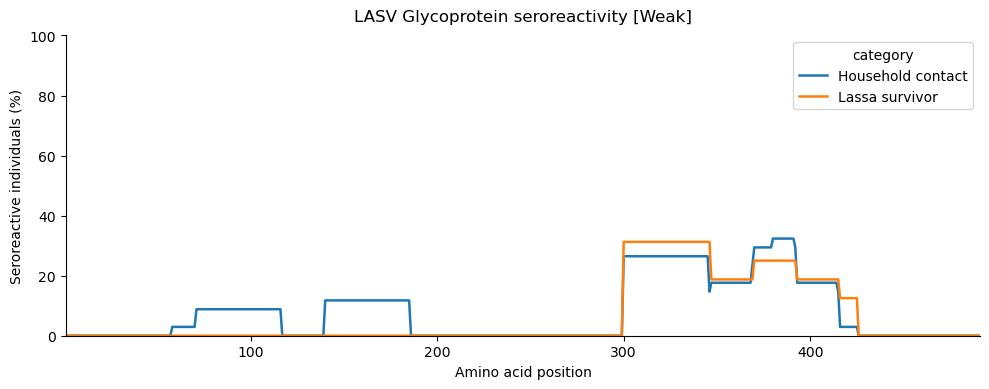

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data= position_summary, 
    x='position', 
    y='pct_seroreactive', 
    hue='category', 
    linewidth=1.8, 
    ax=ax
)

ax.set_xlabel('Amino acid position')
ax.set_ylabel('Seroreactive individuals (%)')
ax.set_xlim(1, len(ref)) #minimum and maximum position
ax.set_ylim(0,  100)

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title('LASV Glycoprotein seroreactivity [Weak]', y=1.02)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('glycoprotein_reactivity_weak_neut_samples.svg', format='svg')
plt.show()

In [61]:
lassa

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,cohort,category,reactive,NP_FINAL_RESULT,GP_FINAL_RESULT,Neut_Percent,Neut_Result,Serology_Result_Corrected
4,AAA46284.1|?|Mammarenavirus_lassaense|?|?|?|?|...,C-192-3_1_D3,-0.652423,0.117829,TERPLSSGVYMGNLSSQQLDQRRALLNMIGMTGVSGGGKGASNGIV,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,nucleoprotein,AAA46284.1,SL,Household contact,False,Positive,Positive,50.557606,Weak,Positive
25,AAO59509.1|polymerase|Mammarenavirus_lassaense...,C-192-3_1_D3,0.143876,0.474583,DNRSDHYEEIIALCHQGINNKLTAHEVKLQIEEEYQVFRNRLRGGE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AAO59509.1,SL,Household contact,False,Positive,Positive,50.557606,Weak,Positive
26,AAO59509.1|polymerase|Mammarenavirus_lassaense...,C-192-3_1_D3,0.187038,0.629512,DGVVVEENLEQLTHQFKRASPILRFLYSDIEGEEDRRNTQAIKEHQ,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AAO59509.1,SL,Household contact,False,Positive,Positive,50.557606,Weak,Positive
27,AAO59509.1|polymerase|Mammarenavirus_lassaense...,C-192-3_1_D3,-0.722601,0.000000,NKRLASFSPVLQDQDLELFVREVGDTSPDLLIGALSAMMLDRLKLR,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AAO59509.1,SL,Household contact,False,Positive,Positive,50.557606,Weak,Positive
333,AHC95546.1|polymerase|Mammarenavirus_lassaense...,C-192-3_1_D3,-1.390351,0.000000,LLDNRSGHYEEIIALCHQGINNKLTAHEVKLQIEEEYQVFRNRLRG,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AHC95546.1,SL,Household contact,False,Positive,Positive,50.557606,Weak,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239962,XBA96071.1|protein|Mammarenavirus_lassaense|LF...,S-504_SA3_D8,4.450602,3.634355,MGNKQAKASEKEKNSPRASLIPDATHLGPQFCKSCWFENKGLVECN,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,z protein,XBA96071.1,SL,Lassa survivor,True,Positive,Positive,61.178632,Weak,Positive
240570,XQN12076.1|polymerase|Mammarenavirus_lassaense...,S-504_SA3_D8,-0.328736,0.969161,DNRSNHYEEVIASCHQGINNKLTAHEVKLQIEEEYQVFRNRLRKGE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,XQN12076.1,SL,Lassa survivor,False,Positive,Positive,61.178632,Weak,Positive
240571,XQN12076.1|polymerase|Mammarenavirus_lassaense...,S-504_SA3_D8,-0.235437,0.484581,IEGQFLKVDKSQLLNELNNLYADKVVAEDNIEHLIYQFKRASPILR,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,XQN12076.1,SL,Lassa survivor,False,Positive,Positive,61.178632,Weak,Positive
240572,XQN12076.1|polymerase|Mammarenavirus_lassaense...,S-504_SA3_D8,2.009613,0.726871,WLGSCFLSVNDRLVSLESTKRDLEKWVERRQQAERSRITQSSQCLS,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,XQN12076.1,SL,Lassa survivor,False,Positive,Positive,61.178632,Weak,Positive
